# 13 - Ordered Factor Variables (Variables Factor Ordenadas)

Algunas variables categoricas tienen un **orden natural**. Por ejemplo, la calidad de construccion va de 1 (cabana) a 13 (mansion).

La pregunta clave: **¿las tratamos como dummies o como numero?**

- Si usamos dummies, **perdemos la informacion del orden** (el modelo no sabe que 7 > 5 > 3)
- Si usamos el numero directamente, **preservamos el orden** y usamos 1 sola columna en vez de P-1

In [8]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

df = pd.read_csv("../data/housing.csv")

# build_quality es nuestra variable factor ordenada (1 a 9)
print("Valores unicos de build_quality (ordenados):")
print(sorted(df["build_quality"].unique()))
print(f"\nDistribucion:")
print(df["build_quality"].value_counts().sort_index())

Valores unicos de build_quality (ordenados):
[np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10)]

Distribucion:
build_quality
1      3
2      6
3     14
4     11
5     11
6     17
7     12
8     12
9      8
10     6
Name: count, dtype: int64


## 1. El ejemplo del libro: Building Grade

El libro usa `BldgGrade` del dataset de King County con esta tabla:

| Valor | Descripcion |
|-------|-------------|
| 1 | Cabin (Cabaña) |
| 2 | Substandard (Inferior) |
| 5 | Fair (Regular) |
| 10 | Very Good (Muy buena) |
| 12 | Luxury (Lujo) |
| 13 | Mansion |

Nuestro `build_quality` es analogo: va de 1 (peor) a 9 (mejor). **El orden importa.**

In [9]:
# Ver la relacion entre build_quality y price
stats = df.groupby("build_quality")["price"].agg(["mean", "count"]).round(0)
stats.columns = ["precio_promedio", "n_casas"]

print("Precio promedio por calidad de construccion:")
print(stats.to_string())
print(f"\n=> A mayor build_quality, mayor precio. HAY un orden claro.")

Precio promedio por calidad de construccion:
               precio_promedio  n_casas
build_quality                          
1                     158000.0        3
2                     217183.0        6
3                     202964.0       14
4                     221636.0       11
5                     202936.0       11
6                     233035.0       17
7                     240867.0       12
8                     268292.0       12
9                     282725.0        8
10                    321617.0        6

=> A mayor build_quality, mayor precio. HAY un orden claro.


## 2. Opcion A: tratar como numero (preservar el orden)

Si `build_quality` es un numero, el modelo asume que la relacion es **lineal**: pasar de 3→4 tiene el mismo efecto que pasar de 7→8.

Esto es simple y eficiente: **1 sola columna.**

In [11]:
# Opcion A: build_quality como numero
predictors_num = ["square_meters", "bathrooms", "build_quality"]

pipe_numeric = Pipeline(
    [
        ("model", LinearRegression()),
    ]
)

X_num = df[predictors_num]
y = df["price"].to_numpy()

pipe_numeric.fit(X_num, y)

coefs = dict(zip(predictors_num, pipe_numeric.named_steps["model"].coef_))
print("Modelo con build_quality como NUMERO:")
print(f"  Intercepto: {pipe_numeric.named_steps['model'].intercept_:,.0f}")
for name, coef in coefs.items():
    print(f"  {name}: {coef:,.2f}")

print(
    f"\n=> Cada punto de build_quality agrega ${coefs['build_quality']:,.0f} al precio"
)
print(f"   Solo 1 columna. Simple y directo.")
print(f"   Columnas usadas: {len(predictors_num)}")

Modelo con build_quality como NUMERO:
  Intercepto: 37,816
  square_meters: 786.78
  bathrooms: 12,416.71
  build_quality: 13,618.94

=> Cada punto de build_quality agrega $13,619 al precio
   Solo 1 columna. Simple y directo.
   Columnas usadas: 3


## 3. Opcion B: tratar como dummies (ignorar el orden)

Si creamos dummies, el modelo trata cada nivel como **independiente**. No asume relacion lineal, pero usa **P-1 columnas** en vez de 1.

In [13]:
# Opcion B: build_quality como dummies
# handle_unknown="ignore" porque con CV, algun fold puede no ver todos los niveles
predictors_base = ["square_meters", "bathrooms"]
predictors_cat = ["build_quality"]

preprocessor_dummy = ColumnTransformer(
    transformers=[
        ("num", "passthrough", predictors_base),
        (
            "cat",
            OneHotEncoder(drop="first", sparse_output=False, handle_unknown="ignore"),
            predictors_cat,
        ),
    ]
)

pipe_dummy = Pipeline(
    [
        ("preprocessor", preprocessor_dummy),
        ("model", LinearRegression()),
    ]
)

X_dummy = df[predictors_base + predictors_cat]
pipe_dummy.fit(X_dummy, y)

# Ver columnas resultantes
cat_names = list(
    pipe_dummy.named_steps["preprocessor"]
    .named_transformers_["cat"]
    .get_feature_names_out()
)
all_names = predictors_base + cat_names
n_dummies = len(cat_names)

print(f"Modelo con build_quality como DUMMIES:")
print(
    f"  Columnas creadas: {n_dummies} dummies (de {df['build_quality'].nunique()} niveles)"
)
print(f"  Total columnas: {len(all_names)}")

lr = pipe_dummy.named_steps["model"]
print(f"\n  Intercepto: {lr.intercept_:,.0f}")
for name, coef in zip(all_names, lr.coef_):
    print(f"  {name}: {coef:,.2f}")

Modelo con build_quality como DUMMIES:
  Columnas creadas: 9 dummies (de 10 niveles)
  Total columnas: 11

  Intercepto: 35,109
  square_meters: 744.54
  bathrooms: 14,057.98
  build_quality_2: 40,197.59
  build_quality_3: 48,652.44
  build_quality_4: 60,960.70
  build_quality_5: 62,601.90
  build_quality_6: 87,632.86
  build_quality_7: 101,125.79
  build_quality_8: 116,094.47
  build_quality_9: 119,102.58
  build_quality_10: 146,120.00


## 4. Comparacion: numerico vs dummies

Ahora la pregunta importante: **¿cual funciona mejor?**

Usamos cross-validation para comparar ambos enfoques.

In [14]:
# Comparar con cross-validation
scores_numeric = cross_val_score(pipe_numeric, X_num, y, cv=5, scoring="r2")
scores_dummy = cross_val_score(pipe_dummy, X_dummy, y, cv=5, scoring="r2")

# Modelo base (sin build_quality)
pipe_base = Pipeline([("model", LinearRegression())])
scores_base = cross_val_score(pipe_base, df[predictors_base], y, cv=5, scoring="r2")

print("Comparacion de enfoques para build_quality:")
print(
    f"  Sin build_quality:       R² CV = {scores_base.mean():.4f} (+/- {scores_base.std():.4f})  | columnas: {len(predictors_base)}"
)
print(
    f"  Como NUMERO (ordenado):  R² CV = {scores_numeric.mean():.4f} (+/- {scores_numeric.std():.4f})  | columnas: {len(predictors_num)}"
)
print(
    f"  Como DUMMIES:            R² CV = {scores_dummy.mean():.4f} (+/- {scores_dummy.std():.4f})  | columnas: {len(all_names)}"
)

print(
    f"\n=> Tratar como numero usa {len(predictors_num)} columnas vs {len(all_names)} columnas con dummies"
)
if scores_numeric.mean() >= scores_dummy.mean():
    print("=> El enfoque numerico es igual o mejor, con MUCHA menos complejidad")
    print("   Esto es porque el ORDEN contiene informacion valiosa")
else:
    print("=> Las dummies capturan una relacion no lineal que el numerico pierde")

Comparacion de enfoques para build_quality:
  Sin build_quality:       R² CV = 0.2911 (+/- 0.2163)  | columnas: 2
  Como NUMERO (ordenado):  R² CV = 0.6896 (+/- 0.1549)  | columnas: 3
  Como DUMMIES:            R² CV = 0.6134 (+/- 0.2061)  | columnas: 11

=> Tratar como numero usa 3 columnas vs 11 columnas con dummies
=> El enfoque numerico es igual o mejor, con MUCHA menos complejidad
   Esto es porque el ORDEN contiene informacion valiosa


## 5. Por que funciona: visualizar la relacion

Si la relacion entre el factor ordenado y el precio es aproximadamente lineal, tratarlo como numero es la mejor opcion.

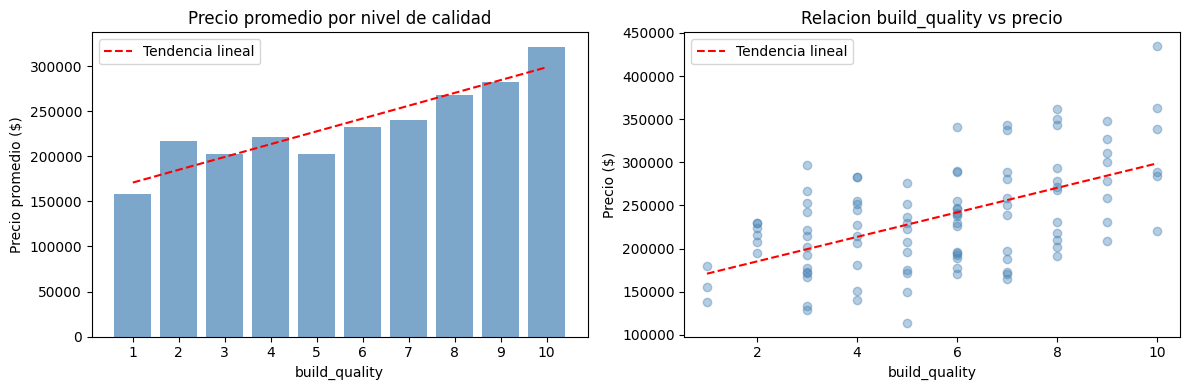

=> Si la tendencia es aproximadamente lineal, tratar como numero es correcto
   Si hubiera saltos o patrones no lineales, las dummies serian mejores


In [15]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Grafico 1: precio promedio por nivel
means = df.groupby("build_quality")["price"].mean()
axes[0].bar(means.index, means.values, color="steelblue", alpha=0.7)
axes[0].set_xlabel("build_quality")
axes[0].set_ylabel("Precio promedio ($)")
axes[0].set_title("Precio promedio por nivel de calidad")
axes[0].set_xticks(means.index)

# Linea de tendencia
z = np.polyfit(means.index, means.values, 1)
axes[0].plot(means.index, np.polyval(z, means.index), "r--", label="Tendencia lineal")
axes[0].legend()

# Grafico 2: scatter plot con regresion
axes[1].scatter(df["build_quality"], df["price"], alpha=0.4, color="steelblue")
x_line = np.linspace(df["build_quality"].min(), df["build_quality"].max(), 100)
axes[1].plot(x_line, np.polyval(z, x_line), "r--", label="Tendencia lineal")
axes[1].set_xlabel("build_quality")
axes[1].set_ylabel("Precio ($)")
axes[1].set_title("Relacion build_quality vs precio")
axes[1].legend()

plt.tight_layout()
plt.show()

print("=> Si la tendencia es aproximadamente lineal, tratar como numero es correcto")
print("   Si hubiera saltos o patrones no lineales, las dummies serian mejores")

## 6. Cuando NO tratar como numero

No todas las variables con numeros son ordenadas. Y no todas las ordenadas tienen relacion lineal.

Ejemplo: imagina un sistema de estrellas donde 1★ y 5★ son caras, pero 3★ es barata (curva en U). Ahi las dummies capturarian mejor el patron.

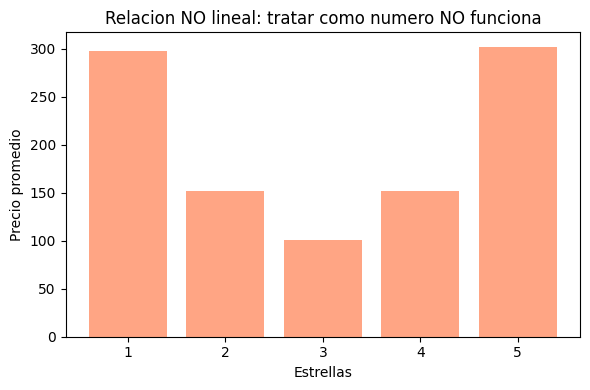

Relacion en U (curvilinea):
  Como numero: R² CV = -0.0265
  Como dummies: R² CV = 0.9649

=> Cuando la relacion NO es lineal, las dummies ganan


In [16]:
# Ejemplo sintetico: relacion NO lineal (curva en U)
np.random.seed(42)
n = 200
stars = np.random.choice([1, 2, 3, 4, 5], size=n)
# Relacion en U: 1 y 5 son caros, 3 es barato
price_u = 100 + 50 * (stars - 3) ** 2 + np.random.normal(0, 15, n)

df_stars = pd.DataFrame({"stars": stars, "price": price_u})

fig, ax = plt.subplots(figsize=(6, 4))
means_u = df_stars.groupby("stars")["price"].mean()
ax.bar(means_u.index, means_u.values, color="coral", alpha=0.7)
ax.set_xlabel("Estrellas")
ax.set_ylabel("Precio promedio")
ax.set_title("Relacion NO lineal: tratar como numero NO funciona")
ax.set_xticks([1, 2, 3, 4, 5])
plt.tight_layout()
plt.show()

# Comparar numerico vs dummies en este caso
y_u = df_stars["price"].to_numpy()

pipe_num_u = Pipeline([("model", LinearRegression())])
scores_num_u = cross_val_score(pipe_num_u, df_stars[["stars"]], y_u, cv=5, scoring="r2")

preprocessor_u = ColumnTransformer(
    [
        ("cat", OneHotEncoder(drop="first", sparse_output=False), ["stars"]),
    ]
)
pipe_dum_u = Pipeline([("pre", preprocessor_u), ("model", LinearRegression())])
scores_dum_u = cross_val_score(pipe_dum_u, df_stars[["stars"]], y_u, cv=5, scoring="r2")

print(f"Relacion en U (curvilinea):")
print(f"  Como numero: R² CV = {scores_num_u.mean():.4f}")
print(f"  Como dummies: R² CV = {scores_dum_u.mean():.4f}")
print(f"\n=> Cuando la relacion NO es lineal, las dummies ganan")

## 7. Guia de decision: ¿numero o dummies?

```
¿La variable tiene un ORDEN natural?
├── NO → Dummies (one hot encoding, P-1)
│        Ejemplo: color, ciudad, tipo de propiedad
│
└── SI → ¿La relacion con Y es aproximadamente lineal?
         ├── SI → Tratar como NUMERO (1 columna)
         │        Ejemplo: build_quality, education_level, loan_grade
         │
         └── NO → Dummies (capturan la no-linealidad)
                  Ejemplo: relaciones en U, saltos entre niveles
```

## 8. Resumen: Key Ideas del libro

| Concepto | Descripcion |
|----------|-------------|
| **Variable factor ordenada** | Categorica con niveles que tienen un orden natural (1 < 2 < 3...) |
| **Tratar como numero** | Usa 1 columna, preserva el orden. Asume relacion lineal |
| **Tratar como dummies** | Usa P-1 columnas, pierde el orden. Captura relaciones no lineales |
| **Cuando usar numero** | El orden importa Y la relacion con Y es aproximadamente lineal |
| **Cuando usar dummies** | No hay orden, o la relacion no es lineal |
| **Ventaja del numero** | Menos columnas = menos parametros = menos riesgo de overfitting |
| **Ejemplo del libro** | `BldgGrade` (1=Cabin → 13=Mansion) se trata como numero en la regresion |